s:\ESR\esr\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - loss: 0.7356 - mae: 1.0971 - val_loss: 1.5506 - val_mae: 1.9724 - learning_rate: 5.0000e-04
Epoch 2/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.4774 - mae: 0.7850 - val_loss: 0.9459 - val_mae: 1.3012 - learning_rate: 5.0000e-04
Epoch 3/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.4076 - mae: 0.6922 - val_loss: 0.6150 - val_mae: 0.9290 - learning_rate: 5.0000e-04
Epoch 4/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.3548 - mae: 0.6177 - val_loss: 0.6011 - val_mae: 0.9340 - learning_rate: 5.0000e-04
Epoch 5/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.3250 - mae: 0.5756 - val_loss: 0.7610 - val_mae: 1.0922 - learning_rate: 5.0000e-04
Epoch 6/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.3017 - mae: 0.5393 - val_loss: 0.6932 - val_mae: 1.0182 - learning_rate: 5.0000e-04
Epoch 7/100
225/225 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.2908 - mae: 0.5201 - val_loss: 0.7819 - val_mae:

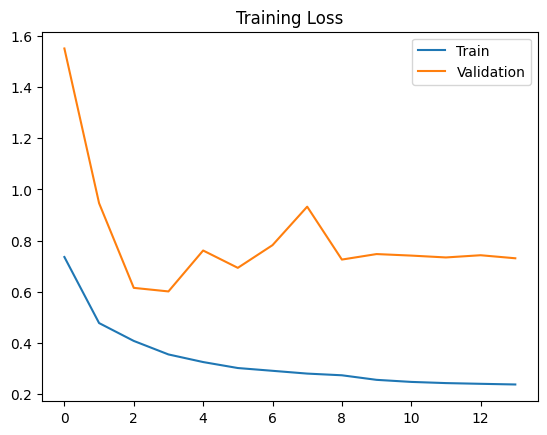

: 

In [ ]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.signal import savgol_filter

# -------------------------------
# Load dataset
# -------------------------------
data = pd.read_csv("final_dataset.csv", header=None)

X = data.iloc[:, :-6].values
y = data.iloc[:, -6:].values

# -------------------------------
# Downsample (speed + stability)
# -------------------------------
X = X[:, ::4]

# -------------------------------
# Preprocessing
# -------------------------------

# 1. Smoothing
for i in range(X.shape[0]):
    X[i] = savgol_filter(X[i], window_length=15, polyorder=3)

# 2. Normalize each spectrum
for i in range(X.shape[0]):
    X[i] = X[i] / np.max(np.abs(X[i]))

# 3. Peak enhancement
X = np.sign(X) * np.sqrt(np.abs(X))

# 4. Gradient feature (VERY IMPORTANT)
X_diff = np.gradient(X, axis=1)
X = np.concatenate([X, X_diff], axis=1)

# -------------------------------
# Train-test split
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# Scaling AFTER split
# -------------------------------
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for CNN
X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)

# -------------------------------
# Final Model
# -------------------------------
model = tf.keras.Sequential([

    tf.keras.layers.Conv1D(32, 5, activation='relu', input_shape=(X_train.shape[1],1)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Conv1D(64, 5, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Conv1D(128, 3, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling1D(2),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(64, activation='relu'),

    tf.keras.layers.Dense(6)
])

# -------------------------------
# Compile
# -------------------------------
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

# -------------------------------
# Callbacks
# -------------------------------
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=5)
]

# -------------------------------
# Train
# -------------------------------
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.1,
    callbacks=callbacks
)

# -------------------------------
# Prediction
# -------------------------------
pred = model.predict(X_test)

# -------------------------------
# Overall Error
# -------------------------------
overall_mae = mean_absolute_error(y_test, pred)
overall_mse = mean_squared_error(y_test, pred)

print("\nOVERALL PERFORMANCE")
print("MAE:", round(overall_mae,4))
print("MSE:", round(overall_mse,4))

# -------------------------------
# Parameter-wise Error
# -------------------------------
names = ["g1","g2","lw1","lw2","A1","A2"]

print("\nPARAMETER-WISE ERRORS\n")

for i, name in enumerate(names):

    mae = mean_absolute_error(y_test[:,i], pred[:,i])
    mse = mean_squared_error(y_test[:,i], pred[:,i])
    rmse = np.sqrt(mse)

    print(f"{name}:")
    print(f"  MAE  = {mae:.4f}")
    print(f"  RMSE = {rmse:.4f}")
    print(f"  MSE  = {mse:.4f}\n")

# -------------------------------
# Plot training curve
# -------------------------------
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.legend()
plt.title("Training Loss")
plt.show()